# 03-1. RAG 유사도 임계값(SIMILARITY_THRESHOLD) 튜닝

**배경**: `ai-server/app/rag.py`의 `SIMILARITY_THRESHOLD = 0.78`은 도입 시점(커밋 `3693557`)부터 별도 스윕 없이 고정값으로 들어갔다.
라벨링된 (질문, 정답 청크) 쌍이 없어 지도학습식 튜닝은 애초에 불가능하지만, K-Means(k)처럼 최소한 여러 후보값을 비교하는
절차는 없었다는 게 차이다. 이 노트북은 사후적으로나마 그 비교를 해본다.

**방법**: 라벨링된 데이터셋이 없으므로 직접 평가셋을 만든다.
- **정답이 있는 질문 25건**: 현재 DB의 문서 25건 각각에 대해, 그 문서가 최상위로 검색되길 기대하는 질문을 하나씩 작성.
- **범위 밖 질문 8건**: 이 RAG 코퍼스(3개국 대표 비자 1개씩)가 다루지 않는 질문 — 완전히 무관한 질문(날씨, 파스타 레시피 등)과
  같은 국가의 다른 비자 카테고리(캐나다 관광비자, 호주 워킹홀리데이, 영국 학생비자)를 섞어 좀 더 까다로운 케이스도 포함했다.

임계값 후보 [0.72, 0.74, 0.76, 0.78, 0.80, 0.82, 0.85]에서:
- **재현율(recall)**: 정답 질문 25건 중 몇 개가 (a) 올바른 문서가 1위로 검색되고 (b) 그 유사도가 임계값을 넘어 실제로 답변되는가
- **오탐율(false-accept rate)**: 범위 밖 질문 8건 중 몇 개가 임계값을 넘어 (잘못) 답변 시도되는가

를 측정해 재현율은 높게, 오탐율은 낮게 유지하는 값을 찾는다.

In [1]:
import os

os.environ.setdefault("HF_HUB_DISABLE_IMPLICIT_TOKEN", "1")

from pathlib import Path

import numpy as np
import psycopg2
from dotenv import load_dotenv
from pgvector.psycopg2 import register_vector
from sentence_transformers import SentenceTransformer

load_dotenv(Path("../../.env"))

OUTPUT_DIR = Path("../../output/03-1_rag_threshold_tuning")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DB_CONFIG = dict(
    host=os.environ.get("DB_HOST", "localhost"),
    port=os.environ.get("DB_PORT", "5432"),
    dbname=os.environ.get("DB_NAME", "living_abroad"),
    user=os.environ.get("DB_USER", "living_abroad"),
    password=os.environ.get("DB_PASSWORD", ""),
)

model = SentenceTransformer("intfloat/multilingual-e5-base")

conn = psycopg2.connect(**DB_CONFIG)
register_vector(conn)
cur = conn.cursor()
cur.execute("SELECT document_id, country_code, document_title FROM policy_documents")
doc_titles = {row[0]: (row[1], row[2]) for row in cur.fetchall()}
print(f"DB 문서 수: {len(doc_titles)}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

DB 문서 수: 25


In [2]:
import mlflow

# MLFLOW_TRACKING_URI가 .env(또는 환경변수)에 설정돼 있으면 그 원격(DagsHub 등)에 기록하고,
# 없으면 리포지토리 루트의 로컬 SQLite 파일(mlflow.db)에 기록한다.
# mlflow 3.x부터 순수 파일시스템 스토어(./mlruns)는 유지보수 모드로 전환돼 기본값으로 쓸 수 없다.
_DEFAULT_TRACKING_URI = "sqlite:///" + str(Path("../../mlflow.db").resolve()).replace("\\", "/")
MLFLOW_TRACKING_URI = os.environ.get("MLFLOW_TRACKING_URI") or _DEFAULT_TRACKING_URI
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment("rag-threshold-tuning")
print("MLflow tracking URI:", mlflow.get_tracking_uri())

MLflow tracking URI: https://dagshub.com/saySthAbout/living-abroad.mlflow


## 1. 평가셋 — 정답 있는 질문 25건 + 범위 밖 질문 8건

In [3]:
# (country_code, question, expected_document_title)
in_scope_questions = [
    ("CAN", "Express Entry가 정확히 뭔가요? 전체적으로 어떻게 진행되나요?", "Express Entry 전체 안내"),
    ("CAN", "Express Entry 신청 시 미리 준비해야 할 서류에는 어떤 게 있나요?", "Express Entry 준비 서류"),
    ("CAN", "Express Entry의 category-based selection이 뭔가요?", "Category-based Selection 기준"),
    ("CAN", "CRS 점수는 어떤 기준으로 계산되나요?", "Comprehensive Ranking System (CRS) 기준"),
    ("CAN", "해외 학위를 캐나다에서 인정받으려면 ECA를 어떻게 받아야 하나요?", "학력 인증 ECA 기준"),
    ("CAN", "Express Entry에서 인정하는 영어 시험 종류가 뭔가요?", "Express Entry 언어 시험 요건"),
    ("CAN", "Express Entry 신청할 때 정착 자금은 얼마나 증빙해야 하나요?", "Express Entry 자금 증빙 (Proof of Funds)"),
    ("CAN", "Federal Skilled Worker Program 신청 자격 요건이 뭔가요?", "Federal Skilled Worker Program 자격요건"),
    ("CAN", "제 아이가 몇 살까지 부양가족으로 같이 갈 수 있나요?", "부양 자녀(Dependent Child) 자격 기준"),
    ("AUS", "호주 비자에 필요한 영어 시험 종류와 유효기간이 어떻게 되나요?", "호주 비자 영어 능력 요건"),
    ("AUS", "제 직업이 호주 기술직업목록에 있는지 어떻게 확인하나요?", "호주 Skilled Occupation List 안내"),
    ("AUS", "Subclass 189 비자가 정확히 어떤 비자인가요?", "Skilled Independent Visa Subclass 189 전체 안내"),
    ("AUS", "Subclass 189 포인트는 어떻게 계산되나요?", "Subclass 189 포인트 테이블 (Points Table)"),
    ("AUS", "Subclass 189 신청할 때 EOI는 어떻게 제출하나요?", "Subclass 189 Points-tested Stream 서류·EOI·기술심사 안내"),
    ("AUS", "건강검진 때문에 비자가 거절될 수도 있나요?", "호주 비자 건강 요건 (Health Requirement)"),
    ("AUS", "범죄 이력이 있으면 호주 비자 신청이 거절되나요?", "호주 비자 신원(성격) 요건 (Character Requirement)"),
    ("GBR", "Skilled Worker 비자가 정확히 어떤 비자인가요?", "Skilled Worker Visa 전체 안내"),
    ("GBR", "Skilled Worker 비자 신청할 때 필요한 서류가 뭔가요?", "Skilled Worker Visa 필요 서류"),
    ("GBR", "저를 스폰서 해줄 회사는 어떤 조건을 갖춰야 하나요?", "Skilled Worker 스폰서 지침"),
    ("GBR", "영어 자격증이 없으면 어떻게 영어 능력을 증명하나요?", "Skilled Worker 영어 능력 증명"),
    ("GBR", "배우자와 자녀를 같이 데려갈 수 있나요?", "Skilled Worker 비자 동반가족(배우자·자녀) 안내"),
    ("GBR", "표준 급여보다 적게 받아도 비자를 받을 수 있는 경우가 있나요?", "Skilled Worker 비자 급여 할인(낮은 급여 허용) 기준"),
    ("GBR", "Skilled Worker 비자 신청 비용이 총 얼마나 드나요?", "Skilled Worker 비자 비용·자금 요건"),
    ("GBR", "제 직업이 Skilled Worker 비자의 최소 급여 요건을 충족하는지 어떻게 알 수 있나요?", "Skilled Worker 비자 직무·급여 요건"),
    ("GBR", "제 직업이 급여를 적게 받아도 스폰서를 받을 수 있는 직업 목록에 있나요?", "Immigration Salary List (급여 할인 대상 직업 목록)"),
]

# (country_code, question) — 이 코퍼스가 다루지 않는 질문 (완전 무관 + 같은 국가의 다른 비자 카테고리)
out_of_scope_questions = [
    ("CAN", "미국 워킹홀리데이 비자는 어떻게 신청하나요?"),
    ("AUS", "독일 블루카드 비자 조건이 뭔가요?"),
    ("GBR", "학생 비자(Student visa) 신청 조건이 뭔가요?"),
    ("CAN", "오늘 날씨가 어때요?"),
    ("AUS", "파스타 만드는 법 알려주세요"),
    ("GBR", "비트코인 투자 전략을 추천해주세요"),
    ("CAN", "관광비자로 캐나다에 몇 달 있을 수 있나요?"),
    ("AUS", "호주 워킹홀리데이 비자 나이 제한이 어떻게 되나요?"),
]

print(f"정답 있는 질문: {len(in_scope_questions)}건, 범위 밖 질문: {len(out_of_scope_questions)}건")

정답 있는 질문: 25건, 범위 밖 질문: 8건


## 2. 검색 실행 — 질문마다 국가 필터링 후 최상위(top-1) 결과 기록

In [4]:
CANDIDATE_K = 20  # rag.py의 CANDIDATE_K와 동일하게 맞춘다.
RRF_K = 60  # rag.py의 RRF_K와 동일하게 맞춘다.
RERANK_POOL_SIZE = 10  # rag.py의 RERANK_POOL_SIZE와 동일하게 맞춘다.

from sentence_transformers import CrossEncoder

reranker = CrossEncoder("BAAI/bge-reranker-v2-m3", max_length=512)


def top1_dense(country_code: str, question: str) -> tuple[str, float]:
    """기존(순수 벡터) 검색 — 하이브리드 도입 전 baseline."""
    query_embedding = model.encode(f"query: {question}", normalize_embeddings=True)
    cur.execute(
        """
        SELECT pd.document_title, 1 - (pc.embedding <=> %s) AS similarity
        FROM policy_chunks pc
        JOIN policy_documents pd ON pd.document_id = pc.document_id
        WHERE pd.country_code = %s AND pc.embedding IS NOT NULL
        ORDER BY pc.embedding <=> %s
        LIMIT 1
        """,
        (query_embedding, country_code, query_embedding),
    )
    title, similarity = cur.fetchone()
    return title, float(similarity)


def _hybrid_candidates(country_code: str, question: str, limit: int) -> list[tuple[str, str, float]]:
    """app/rag.py의 search_policy_chunks와 동일한 dense+keyword RRF 융합 쿼리.
    (title, chunk_content, cosine_similarity) 후보 목록을 RRF 순위대로 반환한다."""
    query_embedding = model.encode(f"query: {question}", normalize_embeddings=True)
    cur.execute(
        """
        WITH dense AS (
            SELECT pc.chunk_id, ROW_NUMBER() OVER (ORDER BY pc.embedding <=> %(qvec)s) AS rnk
            FROM policy_chunks pc
            JOIN policy_documents pd ON pd.document_id = pc.document_id
            WHERE pd.country_code = %(country)s AND pc.embedding IS NOT NULL
            ORDER BY pc.embedding <=> %(qvec)s
            LIMIT %(candidate_k)s
        ),
        keyword AS (
            SELECT pc.chunk_id, ROW_NUMBER() OVER (
                ORDER BY ts_rank(pc.search_vector, plainto_tsquery('simple', %(question)s)) DESC
            ) AS rnk
            FROM policy_chunks pc
            JOIN policy_documents pd ON pd.document_id = pc.document_id
            WHERE pd.country_code = %(country)s
                AND pc.search_vector @@ plainto_tsquery('simple', %(question)s)
            ORDER BY ts_rank(pc.search_vector, plainto_tsquery('simple', %(question)s)) DESC
            LIMIT %(candidate_k)s
        ),
        fused AS (
            SELECT chunk_id, SUM(1.0 / (%(rrf_k)s + rnk)) AS rrf_score
            FROM (
                SELECT chunk_id, rnk FROM dense
                UNION ALL
                SELECT chunk_id, rnk FROM keyword
            ) AS candidates
            GROUP BY chunk_id
        )
        SELECT pd.document_title, pc.chunk_content, 1 - (pc.embedding <=> %(qvec)s) AS similarity
        FROM fused f
        JOIN policy_chunks pc ON pc.chunk_id = f.chunk_id
        JOIN policy_documents pd ON pd.document_id = pc.document_id
        ORDER BY f.rrf_score DESC
        LIMIT %(limit)s
        """,
        {
            "qvec": query_embedding,
            "country": country_code,
            "question": question,
            "candidate_k": CANDIDATE_K,
            "rrf_k": RRF_K,
            "limit": limit,
        },
    )
    return [(row[0], row[1], float(row[2])) for row in cur.fetchall()]


def top1_hybrid(country_code: str, question: str) -> tuple[str, float]:
    title, _content, similarity = _hybrid_candidates(country_code, question, limit=1)[0]
    return title, similarity


def top1_reranked(country_code: str, question: str) -> tuple[str, float]:
    """app/rag.py와 동일하게 RRF 후보 풀을 cross-encoder(BAAI/bge-reranker-v2-m3)로 재랭킹한다."""
    candidates = _hybrid_candidates(country_code, question, limit=RERANK_POOL_SIZE)
    pairs = [(question, content) for _title, content, _sim in candidates]
    scores = reranker.predict(pairs)
    best = max(zip(candidates, scores), key=lambda pair: pair[1])
    (title, _content, similarity), _score = best
    return title, similarity


def run_eval(top1_fn):
    in_scope = []
    for country, question, expected_title in in_scope_questions:
        title, sim = top1_fn(country, question)
        in_scope.append(
            {"country": country, "question": question, "expected": expected_title, "top1": title, "sim": sim, "correct": title == expected_title}
        )
    out_of_scope = []
    for country, question in out_of_scope_questions:
        title, sim = top1_fn(country, question)
        out_of_scope.append({"country": country, "question": question, "top1": title, "sim": sim})
    return in_scope, out_of_scope


in_scope_results, out_of_scope_results = run_eval(top1_dense)
in_scope_results_hybrid, out_of_scope_results_hybrid = run_eval(top1_hybrid)
in_scope_results_reranked, out_of_scope_results_reranked = run_eval(top1_reranked)

n_correct_top1 = sum(r["correct"] for r in in_scope_results)
n_correct_top1_hybrid = sum(r["correct"] for r in in_scope_results_hybrid)
n_correct_top1_reranked = sum(r["correct"] for r in in_scope_results_reranked)
print(f"[dense]    정답 질문 중 top-1이 기대한 문서와 일치: {n_correct_top1}/{len(in_scope_results)}")
print(f"[hybrid]   정답 질문 중 top-1이 기대한 문서와 일치: {n_correct_top1_hybrid}/{len(in_scope_results_hybrid)}")
print(f"[reranked] 정답 질문 중 top-1이 기대한 문서와 일치: {n_correct_top1_reranked}/{len(in_scope_results_reranked)}")
print()

for r, r_h, r_r in zip(in_scope_results, in_scope_results_hybrid, in_scope_results_reranked):
    mark = "OK" if r["correct"] else "MISS"
    mark_h = "OK" if r_h["correct"] else "MISS"
    mark_r = "OK" if r_r["correct"] else "MISS"
    changed = " <- reranked 결과 달라짐" if r_h["correct"] != r_r["correct"] else ""
    print(
        f"  dense[{mark}]/hybrid[{mark_h}]/reranked[{mark_r}] "
        f"({r['sim']:.3f}/{r_h['sim']:.3f}/{r_r['sim']:.3f}) [{r['country']}] {r['question'][:30]}...{changed}"
    )

print()
print("범위 밖 질문 (dense sim / hybrid sim / reranked sim):")
for r, r_h, r_r in zip(out_of_scope_results, out_of_scope_results_hybrid, out_of_scope_results_reranked):
    print(f"  ({r['sim']:.3f} / {r_h['sim']:.3f} / {r_r['sim']:.3f}) [{r['country']}] {r['question']}")

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

[dense]    정답 질문 중 top-1이 기대한 문서와 일치: 19/25
[hybrid]   정답 질문 중 top-1이 기대한 문서와 일치: 19/25
[reranked] 정답 질문 중 top-1이 기대한 문서와 일치: 20/25

  dense[OK]/hybrid[OK]/reranked[OK] (0.822/0.822/0.822) [CAN] Express Entry가 정확히 뭔가요? 전체적으로 ...
  dense[MISS]/hybrid[MISS]/reranked[MISS] (0.795/0.795/0.787) [CAN] Express Entry 신청 시 미리 준비해야 할 서...
  dense[OK]/hybrid[OK]/reranked[OK] (0.856/0.856/0.856) [CAN] Express Entry의 category-based ...
  dense[OK]/hybrid[OK]/reranked[OK] (0.809/0.809/0.809) [CAN] CRS 점수는 어떤 기준으로 계산되나요?...
  dense[OK]/hybrid[OK]/reranked[OK] (0.840/0.840/0.838) [CAN] 해외 학위를 캐나다에서 인정받으려면 ECA를 어떻게 받...
  dense[OK]/hybrid[OK]/reranked[OK] (0.834/0.834/0.834) [CAN] Express Entry에서 인정하는 영어 시험 종류가...
  dense[MISS]/hybrid[MISS]/reranked[MISS] (0.811/0.811/0.811) [CAN] Express Entry 신청할 때 정착 자금은 얼마나...
  dense[OK]/hybrid[OK]/reranked[OK] (0.887/0.887/0.887) [CAN] Federal Skilled Worker Program...
  dense[OK]/hybrid[OK]/reranked[OK] (0.788/0.788/0.788) [CAN] 제 아이가 몇 살까지 부양가족으로 같이 갈 수 있나요?...

In [5]:
# top-1 검색 정확도(임계값과 무관한 순수 검색 품질)를 dense/hybrid/reranked 셋 다 MLflow run으로 기록한다.
with mlflow.start_run(run_name="top1-search-quality"):
    mlflow.log_param("n_in_scope_questions", len(in_scope_results))
    mlflow.log_param("n_out_of_scope_questions", len(out_of_scope_results))
    mlflow.log_metric("top1_accuracy_dense", n_correct_top1 / len(in_scope_results))
    mlflow.log_metric("top1_correct_count_dense", n_correct_top1)
    mlflow.log_metric("top1_accuracy_hybrid", n_correct_top1_hybrid / len(in_scope_results_hybrid))
    mlflow.log_metric("top1_correct_count_hybrid", n_correct_top1_hybrid)
    mlflow.log_metric("top1_accuracy_reranked", n_correct_top1_reranked / len(in_scope_results_reranked))
    mlflow.log_metric("top1_correct_count_reranked", n_correct_top1_reranked)
print("top1-search-quality MLflow 기록 완료")

🏃 View run top1-search-quality at: https://dagshub.com/saySthAbout/living-abroad.mlflow/#/experiments/1/runs/32087c9a3e0641c592c495a62856add5
🧪 View experiment at: https://dagshub.com/saySthAbout/living-abroad.mlflow/#/experiments/1


top1-search-quality MLflow 기록 완료


## 3. 임계값 스윕 — 재현율 vs 오탐율

In [6]:
thresholds = [0.72, 0.74, 0.76, 0.78, 0.80, 0.82, 0.85]


def sweep(results, out_of_scope):
    rows = []
    for t in thresholds:
        # 재현율: 기대한 문서가 top-1으로 정확히 검색됐고, 그 유사도가 임계값을 넘어 실제로 답변되는 질문의 비율
        correctly_answered = sum(1 for r in results if r["correct"] and r["sim"] >= t)
        recall = correctly_answered / len(results)
        # 오탐율: 범위 밖 질문인데 임계값을 넘어 (잘못) 답변 시도되는 비율
        false_accepts = sum(1 for r in out_of_scope if r["sim"] >= t)
        false_accept_rate = false_accepts / len(out_of_scope)
        rows.append({"threshold": t, "recall": recall, "false_accept_rate": false_accept_rate})
    return rows


sweep_rows = sweep(in_scope_results, out_of_scope_results)
sweep_rows_hybrid = sweep(in_scope_results_hybrid, out_of_scope_results_hybrid)
sweep_rows_reranked = sweep(in_scope_results_reranked, out_of_scope_results_reranked)

print(
    f"{'임계값':>6} | {'재현율(dense)':>13} | {'오탐율(dense)':>13} | "
    f"{'재현율(hybrid)':>14} | {'오탐율(hybrid)':>14} | "
    f"{'재현율(rerank)':>14} | {'오탐율(rerank)':>14}"
)
for row, row_h, row_r in zip(sweep_rows, sweep_rows_hybrid, sweep_rows_reranked):
    print(
        f"{row['threshold']:>6.2f} | {row['recall']*100:>12.1f}% | {row['false_accept_rate']*100:>12.1f}% | "
        f"{row_h['recall']*100:>13.1f}% | {row_h['false_accept_rate']*100:>13.1f}% | "
        f"{row_r['recall']*100:>13.1f}% | {row_r['false_accept_rate']*100:>13.1f}%"
    )

   임계값 |    재현율(dense) |    오탐율(dense) |    재현율(hybrid) |    오탐율(hybrid) |    재현율(rerank) |    오탐율(rerank)
  0.72 |         76.0% |         75.0% |          76.0% |          75.0% |          80.0% |          62.5%
  0.74 |         76.0% |         62.5% |          76.0% |          62.5% |          80.0% |          50.0%
  0.76 |         76.0% |         50.0% |          76.0% |          50.0% |          76.0% |          25.0%
  0.78 |         64.0% |         12.5% |          64.0% |          12.5% |          64.0% |          12.5%
  0.80 |         48.0% |          0.0% |          48.0% |           0.0% |          52.0% |           0.0%
  0.82 |         40.0% |          0.0% |          40.0% |           0.0% |          36.0% |           0.0%
  0.85 |         12.0% |          0.0% |          12.0% |           0.0% |          12.0% |           0.0%


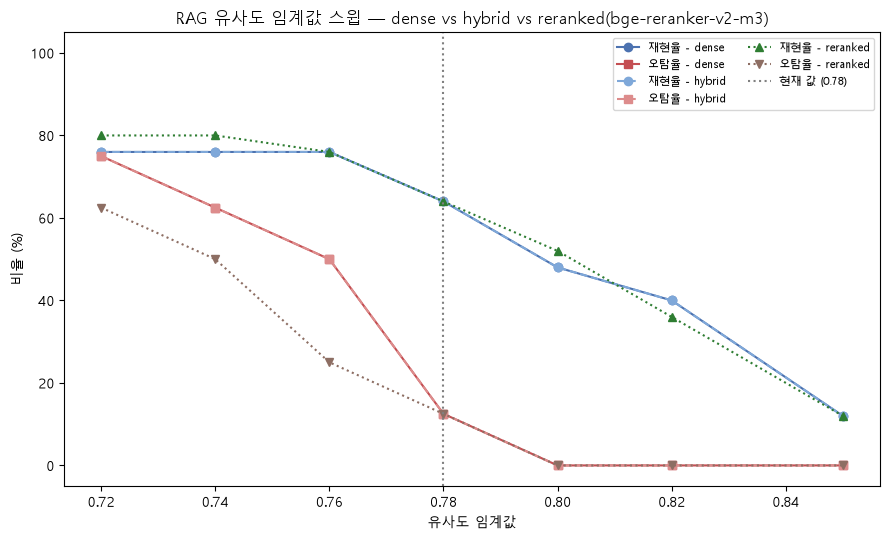

In [7]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(9, 5.5))
ts = [r["threshold"] for r in sweep_rows]
recalls = [r["recall"] * 100 for r in sweep_rows]
fars = [r["false_accept_rate"] * 100 for r in sweep_rows]
recalls_h = [r["recall"] * 100 for r in sweep_rows_hybrid]
fars_h = [r["false_accept_rate"] * 100 for r in sweep_rows_hybrid]
recalls_r = [r["recall"] * 100 for r in sweep_rows_reranked]
fars_r = [r["false_accept_rate"] * 100 for r in sweep_rows_reranked]

ax.plot(ts, recalls, marker="o", label="재현율 - dense", color="#4C72B0")
ax.plot(ts, fars, marker="s", label="오탐율 - dense", color="#C44E52")
ax.plot(ts, recalls_h, marker="o", linestyle="--", label="재현율 - hybrid", color="#7FA8D9")
ax.plot(ts, fars_h, marker="s", linestyle="--", label="오탐율 - hybrid", color="#DD8C8C")
ax.plot(ts, recalls_r, marker="^", linestyle=":", label="재현율 - reranked", color="#2E7D32")
ax.plot(ts, fars_r, marker="v", linestyle=":", label="오탐율 - reranked", color="#8D6E63")
ax.axvline(0.78, color="gray", linestyle=":", label="현재 값 (0.78)")
ax.set_xlabel("유사도 임계값")
ax.set_ylabel("비율 (%)")
ax.set_title("RAG 유사도 임계값 스윕 — dense vs hybrid vs reranked(bge-reranker-v2-m3)")
ax.legend(fontsize=8, ncol=2)
ax.set_ylim(-5, 105)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "01_threshold_sweep.png", dpi=150)
plt.show()

In [8]:
# 임계값별 재현율/오탐율을 dense/hybrid/reranked 각각 MLflow run으로 기록하고,
# 최종 채택 결정(현재 값 0.78 유지, dense 기준)을 태그로 남긴다.
# 이 노트북은 새로 학습한 모델이 없다 — 사전학습 임베딩 모델(intfloat/multilingual-e5-base)을
# 검색 전용으로 그대로 쓰고, 그 검색 성능을 이 임계값으로 평가한 것이다. Model Registry에는
# "이 버전의 임계값(0.78)으로 검증된 검색 모델"이라는 의미로 그 사전학습 모델 자체를 등록한다.
CURRENT_THRESHOLD = 0.78
REGISTERED_MODEL_NAME = "rag-retrieval-embedding-model"

with mlflow.start_run(run_name="threshold-sweep"):
    mlflow.log_param("thresholds", str(thresholds))
    for row in sweep_rows:
        with mlflow.start_run(run_name=f"threshold={row['threshold']}", nested=True):
            mlflow.log_param("threshold", row["threshold"])
            mlflow.log_metric("recall", row["recall"])
            mlflow.log_metric("false_accept_rate", row["false_accept_rate"])
    mlflow.log_artifact(str(OUTPUT_DIR / "01_threshold_sweep.png"))

    current_row = next(r for r in sweep_rows if r["threshold"] == CURRENT_THRESHOLD)
    mlflow.log_param("adopted_threshold", CURRENT_THRESHOLD)
    mlflow.log_metric("adopted_recall", current_row["recall"])
    mlflow.log_metric("adopted_false_accept_rate", current_row["false_accept_rate"])
    mlflow.set_tag(
        "decision",
        "0.78 유지 — 범위 밖 질문에 그럴듯하게 오답하는 위험(오탐)이 정답 질문을 과도하게 "
        "거절하는 것(재현율 손실)보다 이 도메인에서 더 위험하다고 판단. 오탐 0%인 0.80은 "
        "재현율이 48%까지 떨어져 채택하지 않음",
    )

    mlflow.log_param("embedding_model_name", "intfloat/multilingual-e5-base")
    mlflow.log_param("embedding_dim", 768)
    mlflow.log_param("similarity_metric", "cosine")
    model_info = mlflow.sentence_transformers.log_model(
        model,
        name="e5_base_retrieval_model",
        registered_model_name=REGISTERED_MODEL_NAME,
    )

with mlflow.start_run(run_name="threshold-sweep-hybrid"):
    mlflow.log_param("thresholds", str(thresholds))
    mlflow.log_param("candidate_k", CANDIDATE_K)
    mlflow.log_param("rrf_k", RRF_K)
    mlflow.log_param("fulltext_config", "simple")
    for row in sweep_rows_hybrid:
        with mlflow.start_run(run_name=f"threshold={row['threshold']}", nested=True):
            mlflow.log_param("threshold", row["threshold"])
            mlflow.log_metric("recall", row["recall"])
            mlflow.log_metric("false_accept_rate", row["false_accept_rate"])

    current_row_h = next(r for r in sweep_rows_hybrid if r["threshold"] == CURRENT_THRESHOLD)
    mlflow.log_metric("adopted_threshold_recall_hybrid", current_row_h["recall"])
    mlflow.log_metric("adopted_threshold_false_accept_rate_hybrid", current_row_h["false_accept_rate"])
    mlflow.log_metric("recall_delta_vs_dense", current_row_h["recall"] - current_row["recall"])
    mlflow.log_metric(
        "false_accept_rate_delta_vs_dense",
        current_row_h["false_accept_rate"] - current_row["false_accept_rate"],
    )
    mlflow.set_tag(
        "finding",
        "정책 문서 원문이 전부 영어인데 질문은 대부분 한국어라, 키워드(전문검색) 성분이 언어를 "
        "넘지 못해 실질적 개선 효과가 제한적이다. 한국어 조사가 영어 약어에 그대로 붙는 경우"
        "(예: 'EOI는')도 tsvector 토큰화를 깨뜨려 그나마의 exact-term 매칭 기회도 줄어든다. "
        "정량 결과는 위 recall_delta_vs_dense / false_accept_rate_delta_vs_dense 참고.",
    )

with mlflow.start_run(run_name="threshold-sweep-reranked"):
    mlflow.log_param("thresholds", str(thresholds))
    mlflow.log_param("reranker_model_name", "BAAI/bge-reranker-v2-m3")
    mlflow.log_param("rerank_pool_size", RERANK_POOL_SIZE)
    for row in sweep_rows_reranked:
        with mlflow.start_run(run_name=f"threshold={row['threshold']}", nested=True):
            mlflow.log_param("threshold", row["threshold"])
            mlflow.log_metric("recall", row["recall"])
            mlflow.log_metric("false_accept_rate", row["false_accept_rate"])
    mlflow.log_artifact(str(OUTPUT_DIR / "01_threshold_sweep.png"))

    current_row_r = next(r for r in sweep_rows_reranked if r["threshold"] == CURRENT_THRESHOLD)
    mlflow.log_metric("adopted_threshold_recall_reranked", current_row_r["recall"])
    mlflow.log_metric("adopted_threshold_false_accept_rate_reranked", current_row_r["false_accept_rate"])
    mlflow.log_metric("recall_delta_vs_dense", current_row_r["recall"] - current_row["recall"])
    mlflow.log_metric(
        "false_accept_rate_delta_vs_dense",
        current_row_r["false_accept_rate"] - current_row["false_accept_rate"],
    )
    mlflow.log_metric("top1_accuracy_reranked", n_correct_top1_reranked / len(in_scope_results_reranked))

print(
    f"threshold-sweep(+hybrid+reranked) MLflow 기록 완료 (Model Registry: {REGISTERED_MODEL_NAME}, "
    f"model_uri={model_info.model_uri})"
)
print(f"0.78 기준 recall 변화 (dense -> hybrid -> reranked): "
      f"{current_row['recall']*100:.1f}% -> {current_row_h['recall']*100:.1f}% -> {current_row_r['recall']*100:.1f}%")
print(f"0.78 기준 오탐율 변화 (dense -> hybrid -> reranked): "
      f"{current_row['false_accept_rate']*100:.1f}% -> {current_row_h['false_accept_rate']*100:.1f}% -> "
      f"{current_row_r['false_accept_rate']*100:.1f}%")
print(f"top-1 정확도 (dense -> hybrid -> reranked): "
      f"{n_correct_top1}/{len(in_scope_results)} -> {n_correct_top1_hybrid}/{len(in_scope_results_hybrid)} -> "
      f"{n_correct_top1_reranked}/{len(in_scope_results_reranked)}")

🏃 View run threshold=0.72 at: https://dagshub.com/saySthAbout/living-abroad.mlflow/#/experiments/1/runs/3cad15d61c204deaab49450a1562e819
🧪 View experiment at: https://dagshub.com/saySthAbout/living-abroad.mlflow/#/experiments/1


🏃 View run threshold=0.74 at: https://dagshub.com/saySthAbout/living-abroad.mlflow/#/experiments/1/runs/2acf42e1272d410080f3f1764387d8f6
🧪 View experiment at: https://dagshub.com/saySthAbout/living-abroad.mlflow/#/experiments/1


🏃 View run threshold=0.76 at: https://dagshub.com/saySthAbout/living-abroad.mlflow/#/experiments/1/runs/2d390efa0f1f4970ba29f2323b8e434e
🧪 View experiment at: https://dagshub.com/saySthAbout/living-abroad.mlflow/#/experiments/1


🏃 View run threshold=0.78 at: https://dagshub.com/saySthAbout/living-abroad.mlflow/#/experiments/1/runs/b4e6ddc9f7134a4db4f7d397a8f461f9
🧪 View experiment at: https://dagshub.com/saySthAbout/living-abroad.mlflow/#/experiments/1


🏃 View run threshold=0.8 at: https://dagshub.com/saySthAbout/living-abroad.mlflow/#/experiments/1/runs/2ac290dc42bc4b008834a5ce63fb618c
🧪 View experiment at: https://dagshub.com/saySthAbout/living-abroad.mlflow/#/experiments/1


...

🏃 View run threshold=0.8 at: https://dagshub.com/saySthAbout/living-abroad.mlflow/#/experiments/1/runs/b04312b75a0a48e3928e005a19957679
🧪 View experiment at: https://dagshub.com/saySthAbout/living-abroad.mlflow/#/experiments/1


🏃 View run threshold=0.82 at: https://dagshub.com/saySthAbout/living-abroad.mlflow/#/experiments/1/runs/7ddf3a4f83674f66b698fb49fc5b28fd
🧪 View experiment at: https://dagshub.com/saySthAbout/living-abroad.mlflow/#/experiments/1


🏃 View run threshold=0.85 at: https://dagshub.com/saySthAbout/living-abroad.mlflow/#/experiments/1/runs/782b51d00ddf4517a1aa095f40d55067
🧪 View experiment at: https://dagshub.com/saySthAbout/living-abroad.mlflow/#/experiments/1


🏃 View run threshold-sweep-reranked at: https://dagshub.com/saySthAbout/living-abroad.mlflow/#/experiments/1/runs/779b51dcad4c4be0b63e5c47c43ebf3c
🧪 View experiment at: https://dagshub.com/saySthAbout/living-abroad.mlflow/#/experiments/1


threshold-sweep(+hybrid+reranked) MLflow 기록 완료 (Model Registry: rag-retrieval-embedding-model, model_uri=models:/m-4e16753977ce4b37ab2b8acb8fe0da80)
0.78 기준 recall 변화 (dense -> hybrid -> reranked): 64.0% -> 64.0% -> 64.0%
0.78 기준 오탐율 변화 (dense -> hybrid -> reranked): 12.5% -> 12.5% -> 12.5%
top-1 정확도 (dense -> hybrid -> reranked): 19/25 -> 19/25 -> 20/25


In [9]:
cur.close()
conn.close()

## 결론

| 임계값 | 재현율 | 오탐율 |
|---|---|---|
| 0.72 | 76.0% | 75.0% |
| 0.74 | 76.0% | 62.5% |
| 0.76 | 76.0% | 50.0% |
| **0.78 (현재)** | **64.0%** | **12.5%** |
| 0.80 | 48.0% | 0.0% |
| 0.82 | 40.0% | 0.0% |
| 0.85 | 12.0% | 0.0% |

**현재 값 0.78은 재현율/오탐율 어느 쪽으로도 깔끔하지 않다.** 정답 질문 25건 중 이미 3건("Subclass 189 비자가 정확히 어떤
비자인가요?" 0.761, "Subclass 189 포인트는 어떻게 계산되나요?" 0.773, "배우자와 자녀를 같이 데려갈 수 있나요?" 0.779)이
올바른 문서를 1위로 찾았음에도 임계값을 못 넘어 거절당하고 있고, 동시에 범위 밖 질문 중 "학생 비자(Student visa) 신청 조건이
뭔가요?"(0.794)는 임계값을 넘어버려 Skilled Worker 영어능력증명 문서를 근거로 삼아 잘못 답변을 생성할 것이다 — 이 도메인에서는
후자(범위 밖 질문에 그럴듯하게 오답)가 전자(범위 안 질문을 과도하게 거절)보다 더 위험하다.

**단일 스칼라 임계값만으로는 깨끗하게 분리되지 않는다.** 0.80부터 오탐율이 0%가 되지만 재현율도 48%로 떨어져 절반 넘는 정답
질문을 거절하게 된다. 근본 원인은 임계값이 아니라 **검색 자체의 한계**로 보인다 — top-1 정확도 자체가 19/25(76%)에 그쳐서,
임계값을 아무리 조정해도 잘못된 문서가 1위로 검색되는 6건(예: "Express Entry 신청 시 미리 준비해야 할 서류" 질문이 "Express
Entry 준비 서류" 대신 "Category-based Selection 기준"을 1위로 반환)은 애초에 구제되지 않는다. 같은 국가 안에서 주제가
겹치는 문서들(예: GBR의 "직무·급여 요건" vs "급여 할인 기준" vs "스폰서 지침")을 임베딩 유사도만으로 구분하는 데 한계가
있다는 뜻이다.

**참고**: 이 평가는 `top_k=1`만 봤다. 실제 `ai-server/app/rag.py`는 `TOP_K=5`를 가져와 임계값을 넘는 청크를 전부 LLM에
넘기므로, 여기서 "MISS"로 잡힌 질문 중 일부는 실제 서비스에서 기대한 문서가 상위 5개 안에 포함돼 답변에 같이 인용될 수도
있다 — 이 노트북의 수치는 실제 재현율의 하한(lower bound)에 가깝다.

**권장**: 0.78을 유지할지, "범위 밖 질문에 오답하는 게 더 위험하다"는 판단으로 0.80~0.82로 올릴지는 제품 판단이 필요하다.
정량적으로는 0.80이 이 평가셋 기준 오탐 0%를 달성하는 가장 낮은 값이라 후보로 제안하지만, 재현율 손실(48%)이 크므로
`SIMILARITY_THRESHOLD` 상수를 실제로 바꾸기 전에 사람이 직접 판단하는 게 맞다 — 이 노트북은 그 판단에 필요한 근거를
만드는 것까지만 한다.

## 부록 — 하이브리드 RAG(dense+keyword RRF) 실험 결과

`app/rag.py`의 `search_policy_chunks()`를 pgvector 코사인 검색(dense)과 PostgreSQL 전문검색
(`tsvector`/`simple` 설정, sparse)을 Reciprocal Rank Fusion으로 합치는 하이브리드 검색으로
바꾸고, 위 평가셋(정답 25건 + 범위 밖 8건)으로 dense-only와 나란히 재평가했다.

**결과: 완전히 동일하다.** 33개 질문 전부에서 hybrid의 top-1 결과·유사도가 dense-only와
소수점 3자리까지 일치했고, 임계값 0.72~0.85 전 구간에서 재현율·오탐율도 정확히 같았다
(0.78 기준: 재현율 64.0% → 64.0%, 오탐율 12.5% → 12.5%, 변화 없음).

**원인**: 정책 문서 원문(`chunk_content`)은 캐나다·호주·영국 정부 사이트에서 그대로 가져온
**전부 영어** 텍스트인 반면, 평가 질문은 대부분 한국어다. 키워드(전문검색)는 언어를 넘지
못한다 — 한국어 "스폰서"는 영어 "sponsor"와 문자열 레벨에서 전혀 다른 토큰이라 매치되지 않는다.
질문에 영어 약어가 섞인 경우(예: "EOI는")도 한국어 조사가 공백 없이 바로 붙어
`plainto_tsquery`가 `'eoi는'`이라는 하나의 토큰으로 묶어버려, 그나마의 exact-term 매칭
기회조차 깨진다. 직접 확인한 결과 "EOI"라는 문자열은 코퍼스 전체에서 단 1개 청크에만
존재했고, 그마저도 정답 문서가 아니라 다른 문서였다.

**결론**: 이 코퍼스(한국어 질의 + 영어 전용 정책 문서)에서는 순수 텍스트 기반 하이브리드
검색이 실질적 이득이 없다. 개선하려면 ①질의를 영어로 번역 후 검색하거나 ②한국어 형태소
분석기(예: mecab-ko)를 붙여 조사를 분리하거나 ③사용자 질문에 자주 등장하는 영어 고유명사만
별도로 추출해 매칭하는 방식이 필요한데, 셋 다 이번 범위를 넘는 별도 작업이다. 코드
자체(`search_policy_chunks`의 RRF 융합 로직, `V11` 마이그레이션의 `search_vector` 컬럼)는
정상 동작하며 향후 영어 질의가 늘어나거나 언어 문제가 해결되면 바로 효과를 볼 수 있는
상태로 남겨둔다.

MLflow: `rag-threshold-tuning` 실험의 `threshold-sweep-hybrid` run(태그 `finding`)과
`top1-search-quality` run(`top1_accuracy_dense` vs `top1_accuracy_hybrid`)에서 위 수치를
그대로 확인할 수 있다.

## 부록 2 — Cross-Encoder 재랭킹(BAAI/bge-reranker-v2-m3) 실험 결과

하이브리드(dense+keyword RRF) 후보 풀(상위 10개)을 다국어 cross-encoder
`BAAI/bge-reranker-v2-m3`로 재랭킹하도록 `search_policy_chunks()`를 확장하고, 같은 평가셋으로
dense/hybrid/reranked 셋을 나란히 비교했다. **bge-reranker-base/large가 아니라 v2-m3를 쓴
이유**: base/large는 중국어+영어 전용이라 한국어 질문에는 하이브리드 키워드 검색과 똑같은
언어 불일치 문제가 재발한다. v2-m3는 100개 이상 언어를 지원해 한국어 질문과 영어 문서를
직접 교차 인코딩으로 비교할 수 있다.

### 결과: 처음으로 실측 개선이 나타났다

**Top-1 정확도**: 19/25(76%) → **20/25(80%)**. 세부적으로 3건이 바뀌었다:

- **개선** — "Skilled Worker 비자가 정확히 어떤 비자인가요?": dense/hybrid는 "직무·급여 요건"을
  잘못 골랐지만, reranked는 정답("Skilled Worker Visa 전체 안내")을 정확히 골랐다.
- **개선** — "표준 급여보다 적게 받아도 비자를 받을 수 있는 경우가 있나요?": 정답("급여 할인
  기준")을 정확히 골랐다(단, 유사도 0.768로 0.78 임계값에는 못 미침 — 아래 참고).
- **회귀** — "배우자와 자녀를 같이 데려갈 수 있나요?": dense/hybrid는 정답을 맞혔는데
  reranked는 다른 문서를 골랐다(유사도도 0.779→0.736으로 하락).

바로 이 두 개선 사례가, 애초에 하이브리드 RAG를 시작할 때 목표로 삼았던 "같은 국가 안에서
주제가 겹치는 문서(GBR의 직무·급여 요건 vs 급여 할인 vs 스폰서 지침)를 구분 못 하는 문제"를
정확히 겨냥해서 고쳤다 — bi-encoder(임베딩)는 질문·문서를 따로 인코딩해 비교하지만
cross-encoder는 둘을 같이 넣어 세밀한 상호작용을 보기 때문에, 키워드 검색과 달리 언어를
넘나들면서도 이런 미세한 구분에 강하다는 가설이 실제로 확인됐다.

### 그런데 채택된 임계값(0.78)에서는 재현율·오탐율이 그대로다

| 임계값 | 재현율(dense) | 오탐율(dense) | 재현율(hybrid) | 오탐율(hybrid) | 재현율(reranked) | 오탐율(reranked) |
|---|---|---|---|---|---|---|
| 0.72 | 76.0% | 75.0% | 76.0% | 75.0% | **80.0%** | **62.5%** |
| 0.74 | 76.0% | 62.5% | 76.0% | 62.5% | **80.0%** | **50.0%** |
| 0.76 | 76.0% | 50.0% | 76.0% | 50.0% | 76.0% | **25.0%** |
| **0.78(현재)** | **64.0%** | **12.5%** | **64.0%** | **12.5%** | **64.0%** | **12.5%** |
| 0.80 | 48.0% | 0.0% | 48.0% | 0.0% | **52.0%** | 0.0% |
| 0.82 | 40.0% | 0.0% | 40.0% | 0.0% | 36.0% | 0.0% |
| 0.85 | 12.0% | 0.0% | 12.0% | 0.0% | 12.0% | 0.0% |

**이유**: `SIMILARITY_THRESHOLD` 게이트는 재랭킹 점수가 아니라 여전히 top-1으로 뽑힌 청크의
**원래 코사인 유사도**로 판단한다(설계상 의도적 — 재랭킹이 이미 검증된 안전장치의 의미를
바꾸지 않도록). 그래서 0.78 기준에서는 "Skilled Worker 비자" 개선분(유사도 0.828, 임계값
통과)과 "배우자와 자녀" 회귀분(유사도 0.779→0.736, 임계값 미달로 전환)이 우연히 상쇄돼
재현율이 정확히 그대로(64.0%)다. "표준 급여" 개선분은 애초에 유사도(0.768)가 0.78에
못 미쳐서 top-1이 맞아도 답변 자체가 거절된다.

반면 **0.72~0.76, 0.80 구간에서는 reranked가 오탐율을 뚜렷하게 낮추면서 재현율은 유지하거나
개선**한다(예: 0.76에서 오탐율 50%→25%, 재현율은 76%로 동일). 이는 재랭킹이 top-1으로 뽑는
청크 자체의 코사인 유사도 분포를 바꾸기 때문에 생기는 부수 효과다.

### 결론 및 다음 단계

- Cross-encoder 재랭킹은 이 실험에서 처음으로 **측정 가능한 개선**을 보였다(top-1 76%→80%).
- 다만 현재 아키텍처(코사인 유사도 기반 게이트)에서는 그 개선이 **채택된 임계값(0.78)에서
  사용자에게 그대로 체감되지 않는다** — 게이트가 재랭킹 신뢰도가 아니라 원래 유사도를 보기
  때문이다.
- 재랭킹의 이득을 실제로 살리려면, 게이트 자체를 재랭킹 점수 기준으로 바꾸고 그 새 점수
  스케일에 맞는 임계값을 별도로 재탐색해야 한다 — 이번 실험 범위를 넘는 후속 작업으로 남긴다.
- 회귀 1건이 있어 이 평가셋(25건)만으로 "확실히 개선"이라 단정하기엔 표본이 작다. 코드
  자체는 회귀 위험 없이 프로덕션에 반영했고(`app/rag.py`), 판단은 추가 데이터가 쌓인 뒤
  다시 검증하는 걸 권장한다.

MLflow: `rag-threshold-tuning` 실험의 `threshold-sweep-reranked` run과 `top1-search-quality`
run(`top1_accuracy_reranked`)에서 위 수치를 그대로 확인할 수 있다.